# SGD + Split vs Adam Baseline

Can plain SGD with the coupling channel ($W + BC$) match or beat Adam without it?

**Experiments** (all from the same killed-neuron checkpoint):
1. **Adam baseline** — standard parameterization, Adam optimizer
2. **SGD + Split** — add low-rank factors, SGD optimizer, merge+resplit every 10 epochs
3. **SGD baseline** — no factors, SGD optimizer (control)

The coupling channel provides a form of preconditioning through $P = I + \sum_i B_i B_i^\top$ — this could compensate for SGD's lack of adaptive learning rates.

In [1]:
import sys
sys.path.insert(0, "../src")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

from WeightDecomp import DecomposedLinear, DecomposedMLP
from WeightDecomp.train_mnist import train_epoch, evaluate, reset_factor_optimizer_state

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
train_set = torchvision.datasets.MNIST(root="../data", train=True, transform=transform, download=False)
test_set = torchvision.datasets.MNIST(root="../data", train=False, transform=transform, download=False)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=256)

In [3]:
@torch.no_grad()
def count_dead_neurons(model, loader, device, max_batches=50):
    model.eval()
    layers = model.decomposed_layers()
    hidden_layers = layers[:-1]
    max_preact = [torch.full((l.out_features,), -float("inf"), device=device) for l in hidden_layers]
    for batch_idx, (images, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        x = images.to(device).view(images.size(0), -1)
        for i, layer in enumerate(hidden_layers):
            preact = layer(x)
            max_preact[i] = torch.maximum(max_preact[i], preact.max(dim=0).values)
            x = F.relu(preact)
    return {i: (int((mp < 0).sum()), mp.numel()) for i, mp in enumerate(max_preact)}


def kill_neurons(model, frac=0.5, bias_val=-5.0, seed=123):
    rng = torch.Generator().manual_seed(seed)
    for layer in model.decomposed_layers()[:-1]:
        n = layer.out_features
        n_kill = int(n * frac)
        kill_idx = torch.randperm(n, generator=rng)[:n_kill]
        with torch.no_grad():
            layer.bias.data[kill_idx] = bias_val
        print(f"  Killed {n_kill}/{n} neurons (bias <- {bias_val})")

## Create Base Model, Kill Neurons, and Shared Warmup

In [4]:
torch.manual_seed(42)
layer_sizes = [784, 64, 32, 32, 32, 10]

base_model = DecomposedMLP(layer_sizes).to(device)
print("Killing neurons:")
kill_neurons(base_model, frac=0.5, bias_val=-5.0)

dead_init = count_dead_neurons(base_model, train_loader, device)
for i, (d, t) in dead_init.items():
    print(f"  Layer {i}: {d}/{t} dead ({100*d/t:.0f}%)")

# Shared warmup with Adam (so all forks start from same point)
WARMUP_EPOCHS = 2
optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

warmup_dead = [count_dead_neurons(base_model, train_loader, device)]
warmup_losses = []
warmup_accs = []

print(f"\n--- Shared warmup ({WARMUP_EPOCHS} epochs, Adam) ---")
for epoch in range(1, WARMUP_EPOCHS + 1):
    train_loss, _ = train_epoch(base_model, train_loader, optimizer, criterion, device)
    test_acc = evaluate(base_model, test_loader, device)
    warmup_losses.append(train_loss)
    warmup_accs.append(test_acc)
    warmup_dead.append(count_dead_neurons(base_model, train_loader, device))
    dead_str = ", ".join(f"L{i}: {d}/{t}" for i, (d, t) in warmup_dead[-1].items())
    print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Test: {100*test_acc:.2f}% | Dead: [{dead_str}]")

print("\nNow we fork.")

Killing neurons:
  Killed 32/64 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Killed 16/32 neurons (bias <- -5.0)
  Layer 0: 32/64 dead (50%)
  Layer 1: 16/32 dead (50%)
  Layer 2: 21/32 dead (66%)
  Layer 3: 22/32 dead (69%)

--- Shared warmup (2 epochs, Adam) ---
Epoch 1 | Loss: 0.8256 | Test: 89.46% | Dead: [L0: 36/64, L1: 12/32, L2: 14/32, L3: 11/32]
Epoch 2 | Loss: 0.2975 | Test: 92.12% | Dead: [L0: 36/64, L1: 11/32, L2: 13/32, L3: 9/32]

Now we fork.


## Training Function

Supports choosing between Adam and SGD, with optional split + periodic merge.

In [5]:
def continue_training(base_model, optimizer_type="adam", lr=1e-3, momentum=0.9,
                      ranks=None, epochs=40, merge_resplit_every=None):
    model = copy.deepcopy(base_model)
    if ranks:
        model.split_all(ranks)

    if optimizer_type == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    criterion = nn.CrossEntropyLoss()
    dead_counts = [count_dead_neurons(model, train_loader, device)]
    train_losses = []
    test_accs = []

    for epoch in range(1, epochs + 1):
        if (merge_resplit_every and ranks
                and epoch > 1 and (epoch - 1) % merge_resplit_every == 0):
            model.merge_all(rerandomize_B=True)
            reset_factor_optimizer_state(optimizer, model)
            print(f"  [Merge + resplit at post-warmup epoch {epoch}]")

        train_loss, _ = train_epoch(model, train_loader, optimizer, criterion, device)
        test_acc = evaluate(model, test_loader, device)
        train_losses.append(train_loss)
        test_accs.append(test_acc)
        dead_counts.append(count_dead_neurons(model, train_loader, device))

        if epoch % 5 == 0 or epoch == 1:
            dead_str = ", ".join(f"L{i}: {d}/{t}" for i, (d, t) in dead_counts[-1].items())
            print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
                  f"Test: {100*test_acc:.2f}% | Dead: [{dead_str}]")

    return {"dead_counts": dead_counts, "train_losses": train_losses, "test_accs": test_accs}

## Experiment 1: Adam Baseline

In [6]:
POST_EPOCHS = 40

print("=== Adam Baseline ===")
adam_baseline = continue_training(base_model, optimizer_type="adam", lr=1e-3, epochs=POST_EPOCHS)

=== Adam Baseline ===
Epoch   1 | Loss: 0.2414 | Test: 93.15% | Dead: [L0: 36/64, L1: 11/32, L2: 12/32, L3: 10/32]
Epoch   5 | Loss: 0.1389 | Test: 95.37% | Dead: [L0: 36/64, L1: 11/32, L2: 13/32, L3: 9/32]
Epoch  10 | Loss: 0.0982 | Test: 96.30% | Dead: [L0: 36/64, L1: 9/32, L2: 13/32, L3: 9/32]
Epoch  15 | Loss: 0.0772 | Test: 96.52% | Dead: [L0: 36/64, L1: 9/32, L2: 13/32, L3: 9/32]
Epoch  20 | Loss: 0.0619 | Test: 96.61% | Dead: [L0: 36/64, L1: 9/32, L2: 12/32, L3: 8/32]
Epoch  25 | Loss: 0.0549 | Test: 96.56% | Dead: [L0: 36/64, L1: 9/32, L2: 12/32, L3: 8/32]
Epoch  30 | Loss: 0.0464 | Test: 96.41% | Dead: [L0: 36/64, L1: 8/32, L2: 12/32, L3: 7/32]
Epoch  35 | Loss: 0.0412 | Test: 96.20% | Dead: [L0: 36/64, L1: 8/32, L2: 10/32, L3: 8/32]
Epoch  40 | Loss: 0.0332 | Test: 96.50% | Dead: [L0: 36/64, L1: 8/32, L2: 11/32, L3: 7/32]


## Experiment 2: SGD + Split

In [7]:
print("=== SGD + Split (ranks=[4, 8], merge every 10) ===")
sgd_split = continue_training(base_model, optimizer_type="sgd", lr=1e-2, momentum=0.95,
                              ranks=[2, 4, 8], epochs=POST_EPOCHS, merge_resplit_every=10)

=== SGD + Split (ranks=[4, 8], merge every 10) ===
Epoch   1 | Loss: 0.6925 | Test: 92.50% | Dead: [L0: 9/64, L1: 3/32, L2: 2/32, L3: 5/32]
Epoch   5 | Loss: 0.1388 | Test: 95.47% | Dead: [L0: 1/64, L1: 1/32, L2: 2/32, L3: 5/32]
Epoch  10 | Loss: 0.0866 | Test: 96.65% | Dead: [L0: 0/64, L1: 0/32, L2: 2/32, L3: 5/32]
  [Merge + resplit at post-warmup epoch 11]
Epoch  15 | Loss: 0.0544 | Test: 97.17% | Dead: [L0: 0/64, L1: 0/32, L2: 1/32, L3: 3/32]
Epoch  20 | Loss: 0.0391 | Test: 97.10% | Dead: [L0: 0/64, L1: 0/32, L2: 1/32, L3: 3/32]
  [Merge + resplit at post-warmup epoch 21]
Epoch  25 | Loss: 0.0334 | Test: 97.32% | Dead: [L0: 0/64, L1: 0/32, L2: 0/32, L3: 3/32]
Epoch  30 | Loss: 0.0225 | Test: 97.33% | Dead: [L0: 0/64, L1: 0/32, L2: 0/32, L3: 4/32]
  [Merge + resplit at post-warmup epoch 31]
Epoch  35 | Loss: 0.0228 | Test: 97.21% | Dead: [L0: 0/64, L1: 0/32, L2: 1/32, L3: 2/32]
Epoch  40 | Loss: 0.0143 | Test: 97.27% | Dead: [L0: 0/64, L1: 0/32, L2: 0/32, L3: 0/32]


## Experiment 3: SGD Baseline (control)

In [8]:
print("=== SGD Baseline ===")
sgd_baseline = continue_training(base_model, optimizer_type="sgd", lr=1e-2, momentum=0.95,
                                 epochs=POST_EPOCHS)

=== SGD Baseline ===
Epoch   1 | Loss: 0.3124 | Test: 92.43% | Dead: [L0: 36/64, L1: 9/32, L2: 7/32, L3: 6/32]
Epoch   5 | Loss: 0.1446 | Test: 94.95% | Dead: [L0: 36/64, L1: 4/32, L2: 6/32, L3: 2/32]
Epoch  10 | Loss: 0.1028 | Test: 95.66% | Dead: [L0: 36/64, L1: 5/32, L2: 4/32, L3: 2/32]
Epoch  15 | Loss: 0.0832 | Test: 95.72% | Dead: [L0: 36/64, L1: 7/32, L2: 4/32, L3: 2/32]
Epoch  20 | Loss: 0.0684 | Test: 96.31% | Dead: [L0: 36/64, L1: 6/32, L2: 2/32, L3: 1/32]
Epoch  25 | Loss: 0.0587 | Test: 95.58% | Dead: [L0: 36/64, L1: 4/32, L2: 2/32, L3: 1/32]
Epoch  30 | Loss: 0.0519 | Test: 96.44% | Dead: [L0: 36/64, L1: 4/32, L2: 2/32, L3: 0/32]
Epoch  35 | Loss: 0.0464 | Test: 96.32% | Dead: [L0: 36/64, L1: 3/32, L2: 2/32, L3: 0/32]
Epoch  40 | Loss: 0.0460 | Test: 96.66% | Dead: [L0: 36/64, L1: 3/32, L2: 2/32, L3: 0/32]


## Results

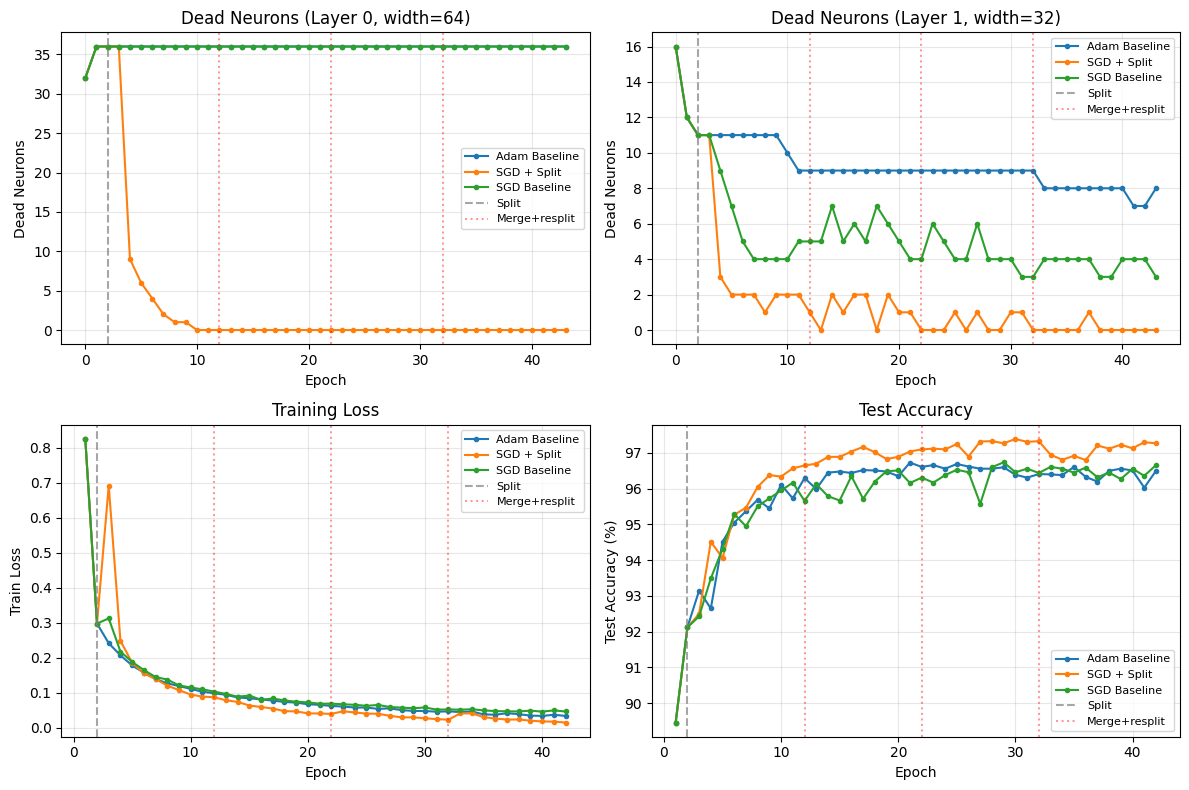

In [9]:
def full_dead_timeseries(warmup_dead, post_result, layer_idx=0):
    warmup = [dc[layer_idx][0] for dc in warmup_dead]
    post = [dc[layer_idx][0] for dc in post_result["dead_counts"]]
    return warmup + post

def full_acc_timeseries(warmup_accs, post_result):
    return warmup_accs + post_result["test_accs"]

def full_loss_timeseries(warmup_losses, post_result):
    return warmup_losses + post_result["train_losses"]

experiments = {
    "Adam Baseline": adam_baseline,
    "SGD + Split": sgd_split,
    "SGD Baseline": sgd_baseline,
}

split_epoch = WARMUP_EPOCHS
merge_epochs = [WARMUP_EPOCHS + e for e in [10, 20, 30]]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

def add_event_lines(ax):
    ax.axvline(x=split_epoch, color="gray", linestyle="--", alpha=0.7, label="Split")
    for i, me in enumerate(merge_epochs):
        ax.axvline(x=me, color="red", linestyle=":", alpha=0.4,
                   label="Merge+resplit" if i == 0 else None)

# Dead neurons layer 0
ax = axes[0, 0]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 0)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=3)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 0, width=64)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Dead neurons layer 1
ax = axes[0, 1]
for name, result in experiments.items():
    ts = full_dead_timeseries(warmup_dead, result, 1)
    ax.plot(range(len(ts)), ts, label=name, marker="o", markersize=3)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Dead Neurons")
ax.set_title("Dead Neurons (Layer 1, width=32)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Train loss
ax = axes[1, 0]
for name, result in experiments.items():
    ts = full_loss_timeseries(warmup_losses, result)
    ax.plot(range(1, len(ts) + 1), ts, label=name, marker="o", markersize=3)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Train Loss")
ax.set_title("Training Loss")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Test accuracy
ax = axes[1, 1]
for name, result in experiments.items():
    ts = full_acc_timeseries(warmup_accs, result)
    ax.plot(range(1, len(ts) + 1), [100 * a for a in ts], label=name, marker="o", markersize=3)
add_event_lines(ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sgd_split_vs_adam.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

Three comparisons on the same axes:

- **Adam Baseline**: adaptive LR but no coupling ($P = I$). Dead neurons in layer 0 stay dead.
- **SGD + Split**: no adaptive LR, but the coupling channel provides preconditioning through $P = I + \sum_i B_i B_i^\top$. Dead neurons can revive.
- **SGD Baseline**: neither adaptive LR nor coupling. Dead neurons stay dead, convergence may be slower.

The coupling channel acts as a structural preconditioner — it reshapes the optimization landscape without changing the function class.